### Tools
Tools can be integrated with the LLM models to interact with external systems. External systems can be API's third party tools.

Whenever a query is asked the model can choose to call the tool and this query is based on the `natural language input` and this will return a output that matches the tool's schema.

In [3]:
def add(a: int, b: int)-> int:
    """ Add a and b
    Args:
        a (int): first int
        b (int): second int
        
    Returns:
        int
    """
    return a+b

## LLM

In [4]:
from langchain_groq import ChatGroq

llm = ChatGroq(model='openai/gpt-oss-120b')
llm_with_tools = llm.bind_tools([add])

### Using messages as state

In [5]:
from typing import TypedDict, Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [6]:
# Chat Node Functionality
def llm_tool(state: State):
    return {'messages': [llm_with_tools.invoke(state['messages'])]}

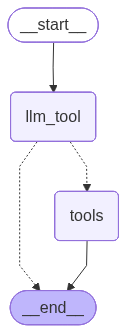

In [9]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

graph = StateGraph(State)

# Node
graph.add_node('llm_tool', llm_tool)
graph.add_node('tools', ToolNode(tools=[add]))

# Edge
graph.add_edge(START, 'llm_tool')
graph.add_conditional_edges('llm_tool', tools_condition)
graph.add_edge('tools', END)

# Compile
graph_builder = graph.compile()

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [10]:
from pprint import pprint

messages = graph_builder.invoke({'messages': 'what is two plus two?'})

for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================

what is two plus two?
================================== Ai Message ==================================

Two plus two equals **4**.


In [11]:
messages = graph_builder.invoke({'messages': 'what is machine learning?'})

for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================

what is machine learning?
================================== Ai Message ==================================

**Machine learning (ML)** is a subfield of artificial intelligence (AI) that focuses on building systems that can learn from data rather than being explicitly programmed for every task. In other words, instead of writing step‑by‑step rules for a computer to follow, we give the computer examples (data) and let it infer the underlying patterns, relationships, or rules on its own.

### Core Ideas

| Concept | What It Means |
|---------|---------------|
| **Data** | The raw material—numbers, text, images, audio, etc.—that the model learns from. |
| **Model** | A mathematical structure (e.g., a neural network, decision tree, or linear equation) that can map inputs to outputs. |
| **Training** | The process of adjusting the model’s internal parameters so that its predictions match known outcomes (labels) 